## Bibliotecas
Aqui importamos as bibliotecas essenciais para trabalhar com séries temporais em Python:
- **numpy**: para operações numéricas
- **pandas**: para manipulação de dados (crucial para time series)
- **datetime e timedelta**: para trabalhar com datas, horas e intervalos de tempo

In [7]:
import numpy as np
import pandas as pd
#para os do objeto datetime
from datetime import datetime
from datetime import timedelta
from matplotlib import pyplot as plt


## Date e usos basicos
Trabalharemos com objetos datetime para entender o básico de manipulação de datas:
- **datetime.now()**: obter a data e hora atual
- **Acessar componentes**: extrair ano, mês, dia, hora de uma data
- **Operações aritméticas**: subtrair datas para obter diferenças
- **timedelta**: criar intervalos de tempo e fazer cálculos
Estas operações são fundamentais para manipular índices de séries temporais.

In [5]:
#chamar o dia de hoje
now = datetime.now()
print(now)

2026-05-21 11:44:36.405124


In [6]:
#pegar os elementos separados de uma data
now.year, now.month, now.day, now.hour

(2026, 5, 21, 11)

In [7]:
#é possivel fazer operacoes com datas
delta = datetime(2011, 9, 7) - datetime(2011, 6, 24, 8, 15)
print(delta)

74 days, 15:45:00


In [8]:
#criar um datatime
start = datetime(2011, 1, 7)
#adicionar 12 dias *2 a uma data
print(start - 2 * timedelta(12))

2010-12-14 00:00:00


In [9]:
#12 dias
timedelta(12)

datetime.timedelta(days=12)

## Converting between string and datetime
Conversões entre strings e objetos datetime são essenciais ao trabalhar com dados reais:
- **str()**: converter datetime para string no formato padrão
- **strftime()**: formatar datas com padrões customizados (ex: '%Y-%m-%d')
- **strptime()**: converter string para datetime especificando o formato esperado
- **pd.to_datetime()**: converter listas de strings para DatetimeIndex (útil para índices de DataFrames)

Veremos exemplos práticos com diferentes formatos de data.

In [10]:
# de datetime para string
stamp = datetime(2011, 1, 3,13)
#aceita a funcao str()
print(str(stamp))

2011-01-03 13:00:00


In [11]:
#ao imprimir a saída em string é possivel determinar o formato
stamp.strftime('%Y %d %m - %I:%M')

'2011 03 01 - 01:00'

In [12]:
#hora em outro formato
stamp.strftime('%Y %d %m - %H:%M')

'2011 03 01 - 13:00'

In [13]:
#de string para datetime
value = "2011-01-03"
#é super importante identificar o formato para entrar no datetime
a = datetime.strptime(value, '%Y-%m-%d')

In [14]:
str(a)

'2011-01-03 00:00:00'

In [15]:
a.day

3

In [16]:
#é possivel usar uma lista como entrada
datestrs = ["7/6/2011", "8/6/2011"]
#usar o pandas para DatetimeIndex que posteriormente pode virar um index de um dataframe
pd.to_datetime(datestrs,format="%d/%m/%Y")

DatetimeIndex(['2011-06-07', '2011-06-08'], dtype='datetime64[us]', freq=None)

## Time Series Basics
Aqui começamos com o essencial de séries temporais em pandas:
- **Série com índice datetime**: criar uma pd.Series com datas como índice
- **Acesso por data**: usar notação de string ou datetime para acessar valores específicos
- **DatetimeIndex**: entender que o índice é do tipo DatetimeIndex, permitindo operações especiais
- **DataFrames com índice temporal**: estrutura para múltiplas variáveis ao longo do tempo
- **Operações com filtros**: usar strings de datas para filtrar por ano, mês ou intervalo
- **Truncamento**: remover dados anteriores ou posteriores a uma data específica

Os exemplos abaixo mostram como criar, acessar e manipular dados temporais.

In [28]:
#criando uma lista de datatimes
dates = [datetime(2011, 1, 2),
         datetime(2011, 1, 5),
         datetime(2011, 1, 7),
         datetime(2011, 1, 8),
         datetime(2011, 1, 10),
         datetime(2011, 1, 12)]

dates

[datetime.datetime(2011, 1, 2, 0, 0),
 datetime.datetime(2011, 1, 5, 0, 0),
 datetime.datetime(2011, 1, 7, 0, 0),
 datetime.datetime(2011, 1, 8, 0, 0),
 datetime.datetime(2011, 1, 10, 0, 0),
 datetime.datetime(2011, 1, 12, 0, 0)]

In [31]:
#criando uma série de valores aleaórios com base na distribuicao normal
ts = pd.Series(np.random.standard_normal(6), index=dates)
ts

2011-01-02    0.457438
2011-01-05    1.181473
2011-01-07    0.449412
2011-01-08    0.638754
2011-01-10    1.230202
2011-01-12   -1.773389
dtype: float64

In [32]:
#aceder a um valor em uma data
ts["2011-01-10"]

np.float64(1.2302024453174425)

In [33]:
#o indice dessa série é um DatetimeIndex
ts.index

DatetimeIndex(['2011-01-02', '2011-01-05', '2011-01-07', '2011-01-08',
               '2011-01-10', '2011-01-12'],
              dtype='datetime64[us]', freq=None)

In [34]:
# se nao fosse uma série
df = pd.DataFrame(np.random.standard_normal((6, 4)),
                  index=dates,
                  columns=['A', 'B', 'C', 'D'])
df

,A,B,C,D
2011-01-02,-0.863710,-0.127488,0.249592,0.729976
2011-01-05,-0.579997,-0.013155,0.001593,0.727698
2011-01-07,0.295110,0.419533,1.697047,0.094094
2011-01-08,-1.152645,0.196360,-1.150353,0.334579
2011-01-10,-1.244859,-0.224351,-0.976654,0.061436
2011-01-12,2.142120,1.474492,-0.716214,0.257948


In [35]:
#aceder a uma linha
df.loc["2011-01-10"]

A   -1.244859
B   -0.224351
C   -0.976654
D    0.061436
Name: 2011-01-10 00:00:00, dtype: float64

In [57]:
#como o filtro é de uma linha retorna uma serie
type(df.loc["2011-01-10"])

pandas.Series

In [58]:
#operacoes com os values associados as datas
ts + ts[::2]

2011-01-02    0.914875
2011-01-05         NaN
2011-01-07    0.898824
2011-01-08         NaN
2011-01-10    2.460405
2011-01-12         NaN
dtype: float64

In [59]:
#criando uma serie de dados com 1000 elementos iniciando em 2000 e seguindo 1000 dias a posterior com valores aleatórios com base na distribuicao normal
longer_ts = pd.Series(np.random.standard_normal(1000), index=pd.date_range("2000-01-01", periods=1000))
longer_ts

2000-01-01   -0.590199
2000-01-02   -0.994176
2000-01-03    0.564973
2000-01-04   -1.178352
2000-01-05    0.038112
                ...   
2002-09-22    1.523762
2002-09-23    0.442088
2002-09-24    0.103577
2002-09-25    0.461306
2002-09-26   -0.077248
Freq: D, Length: 1000, dtype: float64

In [60]:
#filtro por ano
longer_ts["2002"]
#como o indice é um DatetimeIndex, é possível fazer filtros por ano, mês, dia, etc

2002-01-01    0.232085
2002-01-02   -0.927233
2002-01-03   -1.098287
2002-01-04    0.404165
2002-01-05   -0.284592
                ...   
2002-09-22    1.523762
2002-09-23    0.442088
2002-09-24    0.103577
2002-09-25    0.461306
2002-09-26   -0.077248
Freq: D, Length: 269, dtype: float64

In [61]:
longer_ts["2001-05"]

2001-05-01    0.155116
2001-05-02   -0.988249
2001-05-03   -1.871979
2001-05-04   -0.483864
2001-05-05    0.081959
2001-05-06    0.148131
2001-05-07   -0.098329
2001-05-08    0.143557
2001-05-09   -0.481785
2001-05-10   -1.238285
2001-05-11   -1.054871
2001-05-12   -1.977158
2001-05-13   -0.263400
2001-05-14    0.339067
2001-05-15    1.747569
2001-05-16   -2.105436
2001-05-17    0.142292
2001-05-18    1.095028
2001-05-19    0.300404
2001-05-20   -0.120196
2001-05-21   -0.622430
2001-05-22   -0.017125
2001-05-23    1.911155
2001-05-24   -0.095612
2001-05-25   -0.071038
2001-05-26   -1.255451
2001-05-27   -1.376963
2001-05-28    1.020805
2001-05-29   -0.472196
2001-05-30    1.801668
2001-05-31   -1.106267
Freq: D, dtype: float64

In [63]:
longer_ts[datetime(2001, 1, 7):datetime(2001, 1, 10)]

2001-01-07   -0.240081
2001-01-08    0.330444
2001-01-09   -0.952542
2001-01-10    1.053249
Freq: D, dtype: float64

In [64]:
#considerando o ts original
ts

2011-01-02    0.457438
2011-01-05    1.181473
2011-01-07    0.449412
2011-01-08    0.638754
2011-01-10    1.230202
2011-01-12   -1.773389
dtype: float64

In [65]:
#é possivel truncar (jogar fora) valores a partir de uma data
ts.truncate(after="2011-01-09")
#isso nao muda o dataset original, apenas retorna uma nova série

2011-01-02    0.457438
2011-01-05    1.181473
2011-01-07    0.449412
2011-01-08    0.638754
dtype: float64

### Data Range
Criando ranges de datas é crucial para criar índices de séries temporais:
- **pd.date_range()**: gerar sequências de datas com frequência específica (diária, semanal, mensal, etc.)
- **Parâmetros importantes**: start/end (datas limite), periods (quantidade de períodos), freq (frequência)
- **Frequências no pandas**: "W-WED" (toda quarta), "D" (diário), "MS" (mês), etc.
- **Aplicação prática**: criar DataFrames com índices temporais regulares e múltiplas colunas

Veja como criar diferentes tipos de ranges para diferentes necessidades.

In [66]:
dates = pd.date_range("2000-01-01", periods=100, freq="W-WED")
dates

DatetimeIndex(['2000-01-05', '2000-01-12', '2000-01-19', '2000-01-26',
               '2000-02-02', '2000-02-09', '2000-02-16', '2000-02-23',
               '2000-03-01', '2000-03-08', '2000-03-15', '2000-03-22',
               '2000-03-29', '2000-04-05', '2000-04-12', '2000-04-19',
               '2000-04-26', '2000-05-03', '2000-05-10', '2000-05-17',
               '2000-05-24', '2000-05-31', '2000-06-07', '2000-06-14',
               '2000-06-21', '2000-06-28', '2000-07-05', '2000-07-12',
               '2000-07-19', '2000-07-26', '2000-08-02', '2000-08-09',
               '2000-08-16', '2000-08-23', '2000-08-30', '2000-09-06',
               '2000-09-13', '2000-09-20', '2000-09-27', '2000-10-04',
               '2000-10-11', '2000-10-18', '2000-10-25', '2000-11-01',
               '2000-11-08', '2000-11-15', '2000-11-22', '2000-11-29',
               '2000-12-06', '2000-12-13', '2000-12-20', '2000-12-27',
               '2001-01-03', '2001-01-10', '2001-01-17', '2001-01-24',
      

In [67]:
long_df = pd.DataFrame(np.random.standard_normal((100, 4)),index=dates,columns=["Colorado", "Texas","New York", "Ohio"])
long_df

,Colorado,Texas,New York,Ohio
2000-01-05,1.085653,0.611263,1.139733,1.076946
2000-01-12,0.057984,0.528041,0.097477,0.524307
2000-01-19,0.755127,-0.148314,1.047611,1.025034
2000-01-26,-0.857838,-0.148100,0.488811,-0.269503
2000-02-02,1.415897,0.206614,-0.025667,2.618298
...,...,...,...,...
2001-10-31,1.455833,-0.401030,-0.517881,-0.333848
2001-11-07,0.175458,-0.618946,0.795430,0.048152
2001-11-14,-1.253661,0.788113,-0.972159,-1.398179
2001-11-21,0.569741,-0.497056,-0.159257,-2.060417


In [68]:
#isso retorna um dataframe pq o filtro é de mais de uma linha
long_df.loc["2001-05"]

,Colorado,Texas,New York,Ohio
2001-05-02,-1.479727,-0.547127,-0.998075,-1.927837
2001-05-09,-0.367646,-0.064562,-0.234573,1.851942
2001-05-16,0.466410,-0.220172,1.062030,1.979866
2001-05-23,1.284662,-2.044140,-1.344345,-0.836790
2001-05-30,0.588336,0.466811,-0.139544,0.131337


### Duplicated Indices
Às vezes, os dados possuem múltiplas observações para a mesma data (índice duplicado):
- **index.is_unique**: verificar se o índice possui valores duplicados
- **Acesso com índice duplicado**: retorna múltiplos valores
- **groupby(level=0)**: aplicar operações de agregação (média, contagem, soma) para agrupar por índice duplicado
- **Cenários práticos**: múltiplas transações no mesmo dia, múltiplos sensores no mesmo horário, etc.

Veremos como lidar corretamente com estes casos.

In [73]:
#criando um dataset com indices duplicados
dates = pd.DatetimeIndex(["2000-01-01", "2000-01-02", "2000-01-02","2000-01-02", "2000-01-03"])
dup_ts = pd.Series(np.arange(5), index=dates)
dup_ts

2000-01-01    0
2000-01-02    1
2000-01-02    2
2000-01-02    3
2000-01-03    4
dtype: int64

In [74]:
#verificar se há duplicados
dup_ts.index.is_unique

False

In [75]:
dup_ts["2000-01-02"]

2000-01-02    1
2000-01-02    2
2000-01-02    3
dtype: int64

In [77]:
#fazer um groupby para fazer conta com os valores repetidos
dup_ts.groupby(level=0).mean()

2000-01-01    0.0
2000-01-02    2.0
2000-01-03    4.0
dtype: float64

In [78]:
dup_ts.groupby(level=0).count()

2000-01-01    1
2000-01-02    3
2000-01-03    1
dtype: int64

### Ranges, frequecies and shifting
Trabalhamos com diferentes frequências e transformações temporais:
- **pd.date_range()**: criar ranges com frequências diversas (W-THU para quintas, BME para negócios fim de mês, etc.)
- **.shift()**: deslocar os valores de uma série no tempo (positivo = futuro, negativo = passado)
- **Aplicação em retornos**: dividir série deslocada por série original para calcular retornos percentuais
- **Operações com dados defasados**: útil para análise de correlação, momentum e volatilidade

Observe como shift() é essencial para análises de variação temporal.

In [85]:
#criar um range de datas indicando inicio e fim
index = pd.date_range("2012-04-01", "2012-06-01")
index

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20',
               '2012-04-21', '2012-04-22', '2012-04-23', '2012-04-24',
               '2012-04-25', '2012-04-26', '2012-04-27', '2012-04-28',
               '2012-04-29', '2012-04-30', '2012-05-01', '2012-05-02',
               '2012-05-03', '2012-05-04', '2012-05-05', '2012-05-06',
               '2012-05-07', '2012-05-08', '2012-05-09', '2012-05-10',
               '2012-05-11', '2012-05-12', '2012-05-13', '2012-05-14',
               '2012-05-15', '2012-05-16', '2012-05-17', '2012-05-18',
               '2012-05-19', '2012-05-20', '2012-05-21', '2012-05-22',
               '2012-05-23', '2012-05-24', '2012-05-25', '2012-05-26',
      

In [93]:
#quantos dias? 20
pd.date_range(start="2012-04-01", periods=20)

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20'],
              dtype='datetime64[us]', freq='D')

In [94]:
#semanal agarrando nas quintas
index = pd.date_range("2026-05-01", "2026-06-01",freq="W-THU")
index

DatetimeIndex(['2026-05-07', '2026-05-14', '2026-05-21', '2026-05-28'], dtype='datetime64[us]', freq='W-THU')

In [96]:
#bimestral business end of month
pd.date_range("2000-01-01", "2000-12-01", freq="BME")

DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-28',
               '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31',
               '2000-09-29', '2000-10-31', '2000-11-30'],
              dtype='datetime64[us]', freq='BME')

In [102]:
#para testar shift
ts = pd.Series(np.random.standard_normal(4),index=pd.date_range("2000-01-01", periods=4, freq="ME"))
ts

2000-01-31   -0.782389
2000-02-29    1.274885
2000-03-31   -1.117157
2000-04-30    1.255186
Freq: ME, dtype: float64

In [103]:
ts.shift(2)

2000-01-31         NaN
2000-02-29         NaN
2000-03-31   -0.782389
2000-04-30    1.274885
Freq: ME, dtype: float64

In [104]:
ts.shift(-2)

2000-01-31   -1.117157
2000-02-29    1.255186
2000-03-31         NaN
2000-04-30         NaN
Freq: ME, dtype: float64

In [107]:
ts

2000-01-31   -0.782389
2000-02-29    1.274885
2000-03-31   -1.117157
2000-04-30    1.255186
Freq: ME, dtype: float64

In [108]:
ts.shift(1)

2000-01-31         NaN
2000-02-29   -0.782389
2000-03-31    1.274885
2000-04-30   -1.117157
Freq: ME, dtype: float64

In [116]:
(ts / ts.shift(1) -1)

2000-01-31         NaN
2000-02-29   -2.629477
2000-03-31   -1.876281
2000-04-30   -2.123554
Freq: ME, dtype: float64

In [111]:
(1.27/-.78) - 1

-2.628205128205128

### Resampling and Frequency Conversion
Reamostragem é vital para converter séries entre diferentes frequências:
- **.resample()**: converter frequência (ex: diário → mensal, minuto → hora)
- **Métodos de agregação**: .mean(), .sum(), .count(), etc. para agregar dados
- **.asfreq()**: criar novos índices com frequência alvo, preenchendo com NaN para dados faltantes
- **.ffill()** (forward fill): preencher valores faltantes repetindo o último valor conhecido
- **closed, label**: controlar qual extremo do intervalo é incluído (importante para interpretação)
- **PeriodIndex**: trabalhar com períodos (mês, trimestre, ano) em vez de timestamps específicos

Veremos como agregar dados minutários para horas, dias para meses, etc.

In [141]:
#criando dados, 100 dias a partirt de 2000-01-01
dates = pd.date_range("2000-01-01", periods=100)
dates

DatetimeIndex(['2000-01-01', '2000-01-02', '2000-01-03', '2000-01-04',
               '2000-01-05', '2000-01-06', '2000-01-07', '2000-01-08',
               '2000-01-09', '2000-01-10', '2000-01-11', '2000-01-12',
               '2000-01-13', '2000-01-14', '2000-01-15', '2000-01-16',
               '2000-01-17', '2000-01-18', '2000-01-19', '2000-01-20',
               '2000-01-21', '2000-01-22', '2000-01-23', '2000-01-24',
               '2000-01-25', '2000-01-26', '2000-01-27', '2000-01-28',
               '2000-01-29', '2000-01-30', '2000-01-31', '2000-02-01',
               '2000-02-02', '2000-02-03', '2000-02-04', '2000-02-05',
               '2000-02-06', '2000-02-07', '2000-02-08', '2000-02-09',
               '2000-02-10', '2000-02-11', '2000-02-12', '2000-02-13',
               '2000-02-14', '2000-02-15', '2000-02-16', '2000-02-17',
               '2000-02-18', '2000-02-19', '2000-02-20', '2000-02-21',
               '2000-02-22', '2000-02-23', '2000-02-24', '2000-02-25',
      

In [142]:
#criando a serie
ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)
ts

2000-01-01    0.853830
2000-01-02    0.106747
2000-01-03   -1.983926
2000-01-04    0.039397
2000-01-05    0.224241
                ...   
2000-04-05   -0.841030
2000-04-06    0.154109
2000-04-07    0.081275
2000-04-08   -0.305264
2000-04-09    2.436004
Freq: D, Length: 100, dtype: float64

In [143]:
#resampling para Mes START
ts.resample("MS").mean()

2000-01-01    0.079533
2000-02-01   -0.110145
2000-03-01   -0.068323
2000-04-01    0.660367
Freq: MS, dtype: float64

In [144]:
#resampliong para week
ts.resample("W").mean()

2000-01-02    0.480289
2000-01-09   -0.255892
2000-01-16   -0.028921
2000-01-23    0.233346
2000-01-30    0.445589
2000-02-06   -0.272603
2000-02-13   -0.041274
2000-02-20    0.384469
2000-02-27   -0.298777
2000-03-05   -0.816605
2000-03-12    0.134485
2000-03-19    0.442869
2000-03-26   -0.070061
2000-04-02   -0.159320
2000-04-09    0.607843
Freq: W-SUN, dtype: float64

In [147]:
#criando uma serie com base em um intervalo de minutos
dates = pd.date_range("2000-01-01", periods=12, freq="min")
ts = pd.Series(np.arange(len(dates)), index=dates)
ts

2000-01-01 00:00:00     0
2000-01-01 00:01:00     1
2000-01-01 00:02:00     2
2000-01-01 00:03:00     3
2000-01-01 00:04:00     4
2000-01-01 00:05:00     5
2000-01-01 00:06:00     6
2000-01-01 00:07:00     7
2000-01-01 00:08:00     8
2000-01-01 00:09:00     9
2000-01-01 00:10:00    10
2000-01-01 00:11:00    11
Freq: min, dtype: int64

In [151]:
ts["2000-01-01 00:00:00"] = 1
ts

2000-01-01 00:00:00     1
2000-01-01 00:01:00     1
2000-01-01 00:02:00     2
2000-01-01 00:03:00     3
2000-01-01 00:04:00     4
2000-01-01 00:05:00     5
2000-01-01 00:06:00     6
2000-01-01 00:07:00     7
2000-01-01 00:08:00     8
2000-01-01 00:09:00     9
2000-01-01 00:10:00    10
2000-01-01 00:11:00    11
Freq: min, dtype: int64

In [152]:
#a cada 5 min somar
ts.resample("5min").sum()

2000-01-01 00:00:00    11
2000-01-01 00:05:00    35
2000-01-01 00:10:00    21
Freq: 5min, dtype: int64

In [153]:
ts.resample("5min", closed="right").sum()

1999-12-31 23:55:00     1
2000-01-01 00:00:00    15
2000-01-01 00:05:00    40
2000-01-01 00:10:00    11
Freq: 5min, dtype: int64

In [154]:
ts.resample("2min").sum()

2000-01-01 00:00:00     2
2000-01-01 00:02:00     5
2000-01-01 00:04:00     9
2000-01-01 00:06:00    13
2000-01-01 00:08:00    17
2000-01-01 00:10:00    21
Freq: 2min, dtype: int64

In [155]:
#agora com dataframes
frame = pd.DataFrame(np.random.standard_normal((2, 4)),index=pd.date_range("2000-01-01", periods=2,freq="W-WED"),columns=["Colorado", "Texas", "New York", "Ohio"])
frame
#tem um intervalo de dados faltantes ai

,Colorado,Texas,New York,Ohio
2000-01-05,1.344665,0.605386,-1.447462,-0.762712
2000-01-12,0.154900,0.403138,-0.406496,-1.040315


In [157]:
#da pra fazer um resample e ele preenche com NaN os idices faltantes
df_daily = frame.resample("D").asfreq()
df_daily

,Colorado,Texas,New York,Ohio
2000-01-05,1.344665,0.605386,-1.447462,-0.762712
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,0.154900,0.403138,-0.406496,-1.040315


In [159]:
#ou fazer fill com base no anterior
frame.resample("D").ffill()

,Colorado,Texas,New York,Ohio
2000-01-05,1.344665,0.605386,-1.447462,-0.762712
2000-01-06,1.344665,0.605386,-1.447462,-0.762712
2000-01-07,1.344665,0.605386,-1.447462,-0.762712
2000-01-08,1.344665,0.605386,-1.447462,-0.762712
2000-01-09,1.344665,0.605386,-1.447462,-0.762712
2000-01-10,1.344665,0.605386,-1.447462,-0.762712
2000-01-11,1.344665,0.605386,-1.447462,-0.762712
2000-01-12,0.154900,0.403138,-0.406496,-1.040315


In [160]:
frame = pd.DataFrame(np.random.standard_normal((24, 4)),index=pd.period_range("1-2000", "12-2001",freq="M"),columns=["Colorado", "Texas", "New York", "Ohio"])
frame

,Colorado,Texas,New York,Ohio
2000-01,-0.054271,0.971560,1.524472,1.457680
2000-02,0.103297,2.748526,0.961835,-2.389726
2000-03,0.208679,-0.418324,-0.451739,-1.978370
2000-04,1.472932,-1.406570,0.855869,2.317063
2000-05,0.095094,1.046173,-0.127341,0.815523
2000-06,-0.101973,-0.167891,1.700468,3.245143
2000-07,0.434411,0.696969,-1.614683,0.955106
2000-08,-0.595577,0.331320,-0.137007,0.241698
2000-09,0.722002,-0.864925,-1.861509,1.629351
2000-10,-0.706335,1.146873,-0.045536,0.144507


In [163]:
anual = frame.resample("Y-DEC").mean()

In [165]:
anual.resample("Q-DEC").ffill()

,Colorado,Texas,New York,Ohio
2000Q1,0.316345,0.195177,0.076311,0.57716
2000Q2,0.316345,0.195177,0.076311,0.57716
2000Q3,0.316345,0.195177,0.076311,0.57716
2000Q4,0.316345,0.195177,0.076311,0.57716
2001Q1,0.011555,0.264935,0.247599,-0.32599
2001Q2,0.011555,0.264935,0.247599,-0.32599
2001Q3,0.011555,0.264935,0.247599,-0.32599
2001Q4,0.011555,0.264935,0.247599,-0.32599


### Grouped Time Resampling
Às vezes precisamos combinar agrupamento (por categoria) com reamostragem temporal:
- **Dados sem índice temporal**: converter coluna de tempo em índice
- **.resample().count()**: contar observações por período
- **pd.Grouper()**: objeto especial para agrupar simultaneamente por categoria e frequência temporal
- **.groupby(["key", time_key]).sum()**: agregar tanto por categoria quanto por período
- **Caso de uso real**: análise de vendas por loja e por semana, atividades por usuário e hora, etc.

No final, trabalharemos com dados reais de preços de ações: reamostragem, interpolação de dias úteis e média móvel.

In [166]:
#criando um dataframe mas sem colocar as datas como index
N = 15
times = pd.date_range("2017-05-20 00:00", freq="1min", periods=N)
df = pd.DataFrame({"time": times,"value": np.arange(N)})
df

,time,value
0,2017-05-20 00:00:00,0
1,2017-05-20 00:01:00,1
2,2017-05-20 00:02:00,2
3,2017-05-20 00:03:00,3
4,2017-05-20 00:04:00,4
5,2017-05-20 00:05:00,5
6,2017-05-20 00:06:00,6
7,2017-05-20 00:07:00,7
8,2017-05-20 00:08:00,8
9,2017-05-20 00:09:00,9


In [167]:
#forcando a data como index
df.set_index("time").resample("5min").count()

,value
time,
2017-05-20 00:00:00,5
2017-05-20 00:05:00,5
2017-05-20 00:10:00,5


In [170]:
df2 = pd.DataFrame({"time": times.repeat(3),"key": np.tile(["a", "b", "c"], N),"value": np.arange(N * 3.)})
df2.head(7)

,time,key,value
0,2017-05-20 00:00:00,a,0.0
1,2017-05-20 00:00:00,b,1.0
2,2017-05-20 00:00:00,c,2.0
3,2017-05-20 00:01:00,a,3.0
4,2017-05-20 00:01:00,b,4.0
5,2017-05-20 00:01:00,c,5.0
6,2017-05-20 00:02:00,a,6.0


In [173]:
#instrucao para agrupar em 5 em 5 min
time_key = pd.Grouper(freq="5min")
#cria um resampled agrupando grupo e timekey e forcando time como index
resampled = (df2.set_index("time").groupby(["key", time_key]).sum())
resampled

value
key time                      
a   2017-05-20 00:00:00   30.0
    2017-05-20 00:05:00  105.0
    2017-05-20 00:10:00  180.0
b   2017-05-20 00:00:00   35.0
    2017-05-20 00:05:00  110.0
    2017-05-20 00:10:00  185.0
c   2017-05-20 00:00:00   40.0
    2017-05-20 00:05:00  115.0
    2017-05-20 00:10:00  190.0

In [179]:
#read txt from ./data folder
close_px_all = pd.read_csv("./data/stock_px.csv",parse_dates=True, index_col=0)
close_px_all

,AAPL,MSFT,XOM,SPX
2003-01-02,7.40,21.11,29.22,909.03
2003-01-03,7.45,21.14,29.24,908.59
2003-01-06,7.45,21.52,29.96,929.01
2003-01-07,7.43,21.93,28.95,922.93
2003-01-08,7.28,21.31,28.83,909.93
...,...,...,...,...
2011-10-10,388.81,26.94,76.28,1194.89
2011-10-11,400.29,27.00,76.27,1195.54
2011-10-12,402.19,26.96,77.16,1207.25
2011-10-13,408.43,27.18,76.37,1203.66


In [183]:
close_px = close_px_all[["AAPL", "MSFT", "XOM"]]
close_px

,AAPL,MSFT,XOM
2003-01-02,7.40,21.11,29.22
2003-01-03,7.45,21.14,29.24
2003-01-06,7.45,21.52,29.96
2003-01-07,7.43,21.93,28.95
2003-01-08,7.28,21.31,28.83
...,...,...,...
2011-10-10,388.81,26.94,76.28
2011-10-11,400.29,27.00,76.27
2011-10-12,402.19,26.96,77.16
2011-10-13,408.43,27.18,76.37


In [182]:
close_px = close_px.resample("B").ffill()
close_px

,AAPL,MSFT,XOM
2003-01-02,7.40,21.11,29.22
2003-01-03,7.45,21.14,29.24
2003-01-06,7.45,21.52,29.96
2003-01-07,7.43,21.93,28.95
2003-01-08,7.28,21.31,28.83
...,...,...,...
2011-10-10,388.81,26.94,76.28
2011-10-11,400.29,27.00,76.27
2011-10-12,402.19,26.96,77.16
2011-10-13,408.43,27.18,76.37


<Axes: >

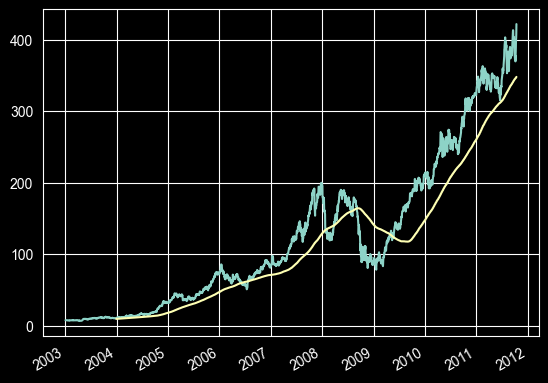

In [186]:
close_px["AAPL"].plot()
close_px["AAPL"].rolling(250).mean().plot()

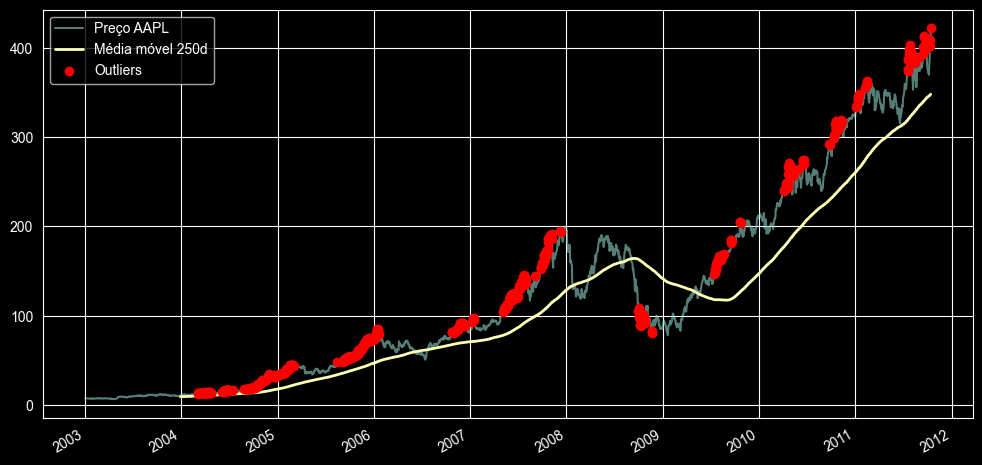

In [195]:
import matplotlib.pyplot as plt

aapl = close_px["AAPL"]

# Média móvel de 250 dias
mean_1000 = aapl.rolling(200).mean()

# Desvio padrão móvel
std_1000 = aapl.rolling(200).std()

# Banda superior e inferior (2 desvios padrão)
upper = mean_1000 + 2 * std_1000
lower = mean_1000 - 2 * std_1000

# Identificar outliers
outliers = (aapl > upper) | (aapl < lower)

# Plot
plt.figure(figsize=(12,6))

aapl.plot(label="Preço AAPL", alpha=0.6)
mean_250.plot(label="Média móvel 250d", linewidth=2)

plt.scatter(
    aapl.index[outliers],
    aapl[outliers],
    color="red",
    label="Outliers",
    zorder=5
)

plt.legend()
plt.show()

### Desafio — Análise Temporal de Séries Financeiras

Considerando o dataset `stock_px.csv`, responda:

1. Apresente:
   - dimensão do dataset
   - período temporal disponível
   - quantidade de ativos analisados

2. Identifique:
   - quais ativos possuem valores ausentes
   - percentual de valores ausentes por ativo

3. Selecione apenas os ativos:

```python
["AAPL", "MSFT", "XOM"]
```
Faça um gráfico temporal das séries. Qual ativo aparenta possuir maior volatilidade visual?

4. Faça um reamostramento semanal (`resample`) dos preços e calcule:
   - média semanal
   - último preço da semana

Existe diferença entre utilizar média semanal e último preço semanal? Qual faz mais sentido para representar fechamento financeiro?

5. Faça um reamostramento mensal (`resample("M")`) para AAPL e calcule:
   - máximo mensal
   - mínimo mensal
   - amplitude mensal

Amplitude = Máximo - Mínimo

Qual mês apresentou maior amplitude?


In [3]:
close_px_all = pd.read_csv("./data/stock_px.csv",parse_dates=True, index_col=0)
close_px_all

,AAPL,MSFT,XOM,SPX
2003-01-02,7.40,21.11,29.22,909.03
2003-01-03,7.45,21.14,29.24,908.59
2003-01-06,7.45,21.52,29.96,929.01
2003-01-07,7.43,21.93,28.95,922.93
2003-01-08,7.28,21.31,28.83,909.93
...,...,...,...,...
2011-10-10,388.81,26.94,76.28,1194.89
2011-10-11,400.29,27.00,76.27,1195.54
2011-10-12,402.19,26.96,77.16,1207.25
2011-10-13,408.43,27.18,76.37,1203.66
